In [1]:
from itertools import *
import seaborn as sea
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ase import Atoms
from ase.visualize import view
from random import sample,seed
from shape_proj_util.geo_tools.geometry import *
from ase.io.xyz import write_xyz
from scipy.spatial.distance import cdist
import random
from tqdm.auto import tqdm
from scipy.spatial import ConvexHull,QhullError
from scipy.spatial import cKDTree
from time import time
from ase.io import write


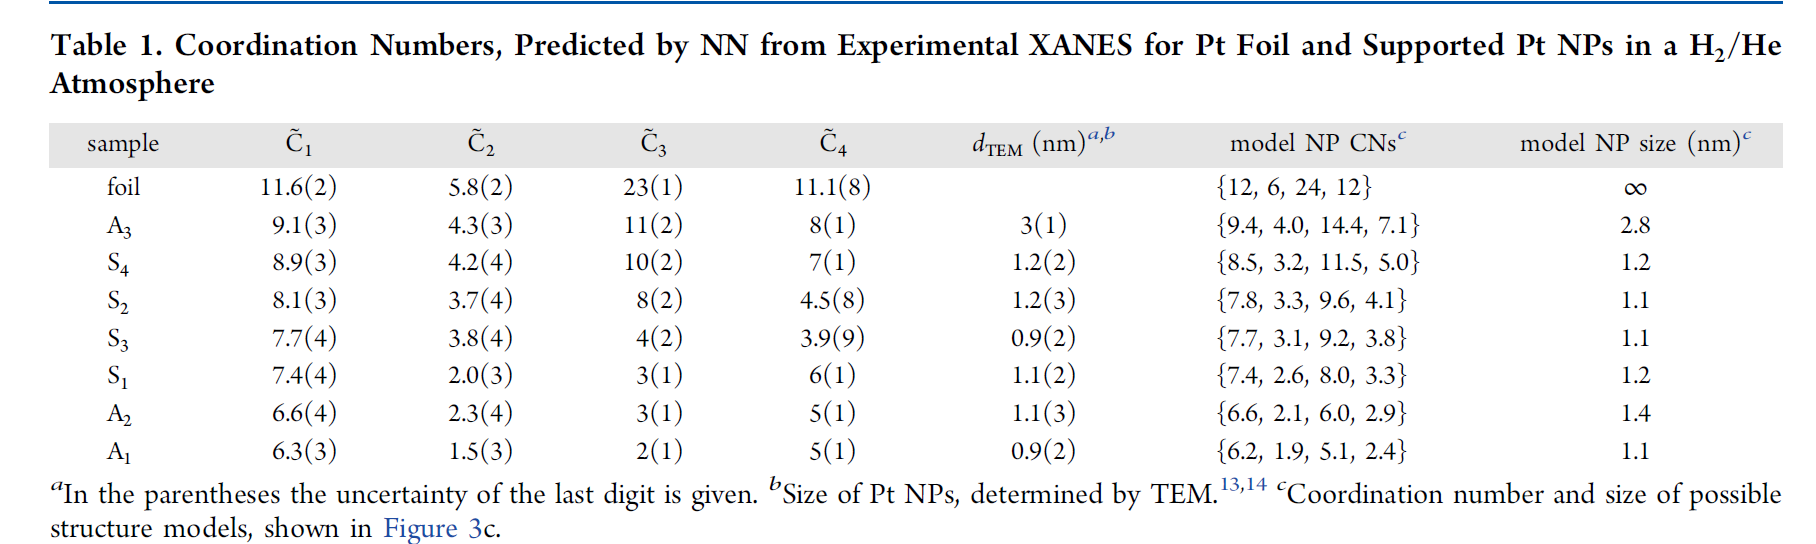

In [2]:
#a: lattice constant
#x,y,z are how many times lattice extends along this direction
#x,y,z must large than 1
def fccbasis(a):
    fcc = [
        [0, 0.5 * a, 0.5 * a],
        [0.5 * a, 0, 0.5 * a],
        [0.5 * a, 0.5 * a, 0],
        [0, 0, 0],
    ]
    return np.array(fcc)

#lattice is an array containing coordinates in fcc
# lattice is an array containing coordinates in fcc
def extendfcc(lattice, a, x, y, z):
    lattice_extend = []
    for i in range(0, x):
        for j in range(0, y):
            for k in range(0, z):
                for o in range(0, len(lattice)):
                    if not lattice_extend.__contains__(
                        [
                            lattice[o][0] + i * a,
                            lattice[o][1] + j * a,
                            lattice[o][2] + k * a,
                        ]
                    ):
                        lattice_extend.extend(
                            [
                                [
                                    lattice[o][0] + i * a,
                                    lattice[o][1] + j * a,
                                    lattice[o][2] + k * a,
                                ]
                            ]
                        )
    return np.array(lattice_extend)

In [3]:
def empty_lattice(lc, n1, n2, n3):
    """
    Generate a fcc lattice by given lattice constant and superlattice parameters: n1,n2,n3.
    The constructed lattice is centered at (0,0,0), and the coordinates are reordered by the
    atom to center distance.
    @param lc: lattice constant
    @param n1: superlattice parameter: number of cells on x direction
    @param n2: superlattice parameter: number of cells on y direction
    @param n3: superlattice parameter: number of cells on z direction
    @param mid_position: the position of the center of the lattice, if None, the center of the lattice is set to (0,0,0)
    return: ordered lattice, mid_position
    """

    # lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    lattice = extendfcc(fccbasis(lc), lc, n1, n2, n3)
    mid_position = np.mean(lattice, axis=0)
    lattice=np.round(lattice-mid_position,6)
    x_max, y_max, z_max = np.max(lattice, axis=0)
    x_min, y_min, z_min = np.min(lattice, axis=0)
    
    # lattice=order_pos(lattice)
    lattice = lattice[
        np.where(
            (lattice[:, 0] >= x_min)
            & (lattice[:, 0] <= x_max)
            & (lattice[:, 1] >= y_min)
            & (lattice[:, 1] <= y_max)
            & (lattice[:, 2] >= z_min)
            & (lattice[:, 2] <= z_max)
        )
    ]
    return order_pos(lattice)


def order_pos(lattice, mid_position=None):
    if mid_position is None:
        mid_position = np.mean(lattice, axis=0)
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist = np.round(cdist([mid_position], lattice), 6)
    dist_dict = Counter(dist[0])
    sorted_count = sorted(dist_dict.items(), key=lambda x: x[0], reverse=False)
    record = []
    ordered_particle = []
    for i in range(len(sorted_count)):
        record.extend(np.where(dist == sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)



def particles_encode_gen_no_oblate(lc, lattice_big, num_atoms=None, max_num_atoms=None):
    if num_atoms == None:
        assert (
            max_num_atoms != None
        ), "Please provide the maximum number of atoms in the lattice."
        num_atoms = random.randint(12, max_num_atoms)
    # min_num_points=num_atoms
    num_lattice = max_num_atoms #//2
    n_max = int(np.ceil(np.cbrt(num_lattice)))
    num_points = 0
    # transfer points to the big lattice
    indices = []
    # genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(
            np.where(
                np.all(np.isclose(lattice_big, lattice_big[i], rtol=1e-3), axis=1)
            )[0]
        )
    return lattice_big[indices]


# generate structures in a lattice with random dimensions (n1,n2,n3) in a bigger existed lattice and random numbers of atoms.
# inidividual structure was filled with atoms in the order of distance to the center of the lattice.
def particles_encode_gen(lc, num_atoms=None, max_num_atoms=None,record_lattice=[]):
    if num_atoms == None:
        # assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms = random.randint(12, max_num_atoms)
    num_lattice = max_num_atoms//4 #// 2
    # min_num_points=num_atoms

    # print(f"length={np.mean(lattice_big,axis=0)}")
    # times=random.randint(1,3)
    # the extreme case is that the particle has only one layer of unit cells, which has the dimension: np.sqrt(n_max**3)*np.sqrt(n_max**3)*1
    n1 = random.randint(2, int(np.sqrt(num_lattice)))
    n2 = random.randint(2, int(np.sqrt(num_lattice)))
    n3 = random.randint(1, int(np.sqrt(num_lattice)))
    # n3 = random.randint(1, int(np.sqrt(num_lattice)))
    # n1 = random.randint(n3, int(np.sqrt(num_lattice)))
    # n2=n1
    
    lattice = empty_lattice(lc, n1, n2, n3)
    num_points = len(lattice)
    # this is too strong
    while num_points <= num_atoms or [n1,n2,n3,num_atoms] in record_lattice:
        if num_atoms == None:
            # assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
            num_atoms = random.randint(12, max_num_atoms)
        n1 = random.randint(1, int(np.sqrt(num_lattice)))
        n2 = random.randint(1, int(np.sqrt(num_lattice)))
        n3 = random.randint(1, int(np.sqrt(num_lattice)))
        # n3 = random.randint(1, int(np.sqrt(num_lattice)))
        # n1 = random.randint(n3, int(np.sqrt(num_lattice)))
        # n2=n1
        lattice = empty_lattice(lc, n1, n2, n3)
        num_points = len(lattice)
    record_lattice.append([n1,n2,n3,num_atoms])
    # print(record_lattice)
    lattice = lattice[:num_atoms]

    return lattice,record_lattice


def ini_population(
    lc, population_size, num_atoms=None, max_num_atoms=None,lc_record=[]
):
    generations = []
    n = 0
    for i in range(population_size):
        particle,lc_record = particles_encode_gen(
            lc,
            num_atoms=num_atoms,
            max_num_atoms=max_num_atoms,
            record_lattice=lc_record #record lattice numbers to avoid duplicates
        )
        # print(nn)
        generations.append(particle)
    return generations,lc_record


def fitness(particle, descriptors: dict, fitness_func="L1", reduction="sum",weight:np.ndarray=None):
    if weight==None:
        weight=np.array([1]*len(descriptors.keys()))
    atom = Atoms(positions=particle, symbols=["Pt"] * len(particle))
    try:
        if "oblateness_moment" not in descriptors.keys():
            cluster_descriptors = descriptor_table(
            atom, all=False, descriptors=list(descriptors.keys()) + ["oblateness_moment"]
            )
        else:
            cluster_descriptors = descriptor_table(
                atom,all=False,descriptors=list(descriptors.keys())
            )
    except RuntimeWarning:
        print(f"calculate descriptor: {atom.get_positions()}")
    true_dis = []
    for k in descriptors.keys():
        if k != "ellipsoid":
            true_dis.append(descriptors[k])
        else:
            true_dis.append(descriptors[k][0])
            true_dis.append(descriptors[k][1])
            true_dis.append(descriptors[k][2])
    true_dis = np.array(true_dis)
    # print(true_dis)
    if "oblateness_moment" not in descriptors.keys():
        pred_dis = np.array(
            [cluster_descriptors[k] for k in list(cluster_descriptors.keys())[:-1]]
        )
    else:
        pred_dis=np.array([cluster_descriptors[k] for k in list(cluster_descriptors.keys())])
    # print(pred_dis)
    # MSE
    # np.sum((true_dis-pred_dis)**2)
    sim = 0
    if cluster_descriptors["oblateness_moment"] > 1:
        if fitness_func=="L1":
            sim = np.abs(true_dis - pred_dis)
        elif fitness_func=="L2":
            sim = np.power(true_dis - pred_dis, 2)
        elif fitness_func=="RAE":
            sim = (np.abs(true_dis - pred_dis) / true_dis)

        if reduction=="sum":
            sim = np.dot(sim,weight) * 10 ** cluster_descriptors["oblateness_moment"]
        elif reduction=="mean":
            sim = np.dot(sim,weight)/np.sum(weight) * 10 ** cluster_descriptors["oblateness_moment"]
        elif reduction=="max":
            sim = np.max(np.multiply(sim,weight)) * 10 ** cluster_descriptors["oblateness_moment"]
    else:
        if fitness_func=="L1":
            sim = np.abs(true_dis - pred_dis)
            # print(sim)
        elif fitness_func=="L2":
            sim = np.power(true_dis - pred_dis, 2)
        elif fitness_func=="RAE":
            sim = (np.abs(true_dis - pred_dis) / true_dis)
        if reduction=="sum":
            sim = np.sum(sim) 
        elif reduction=="mean":
            sim = np.mean(sim) 
        elif reduction=="max":
            sim = np.max(sim)
    return sim, pred_dis




def parents(population, fitness_values, tol=1e5):
    fitness_values = np.array(fitness_values)
    ranking = ranking_fitness(fitness_values)
    prob = normalized_p(ranking)
    # index=np.arange(len(population))
    # threshold=random.uniform(np.min(prob),np.max(prob))
    current = 0
    index = 0
    # for i in range(len(population)):
    while index < tol:
        i = random.randint(0, len(population) - 1)
        index += 1
        if random.uniform(0, 1) <= prob[i]:
            return list(population[i])
        if index == tol:
            raise Exception("exceed the maximum try times!")


def ranking_fitness(fitness_values):
    fitness_ranking = np.zeros(len(fitness_values))
    fitness_dict = Counter(fitness_values)
    fitness_ordered = sorted(fitness_dict.keys(), reverse=False)
    rank = 1
    for i in range(len(fitness_ordered)):
        indices = np.where(np.array(fitness_values) == fitness_ordered[i])[0]
        for j in indices:
            fitness_ranking[j] = rank
        rank += 1
    return fitness_ranking


def probability_selection(fitness_ranking):
    R = len(fitness_ranking)
    lamb = np.log(10) / (max(fitness_ranking) - min(fitness_ranking))
    # print(lamb)
    z = np.array([np.exp(-lamb * r) for r in fitness_ranking])
    z_sum = np.sum(z)
    return z / z_sum



def normalized_p(fitness_ranking):
    p = probability_selection(fitness_ranking)
    return (p - np.min(p)) / (np.max(p) - np.min(p))


def atom_cut_up_down_center(particle, theta, phi,center_method="mean"):
    def normal_vector(center,theta, phi):
        return np.array(
            [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
        )

    num_atoms = len(particle)
    particle = np.array(particle)
    if num_atoms < 5:
        print("Warning particle is less than 5 atoms")
        return particle, particle

    particle = np.array(particle)
    
    # for i in range(len(particle)):
    #     CN1,dis=getCN_dis_Oneshell(particle,particle[i],1,thickness=0.1)
    #     if CN1==12:
    #         center_get.append(particle[i])
    # if len(center_get)!=0:

    min_dim=np.min(particle,axis=0)
    max_dim=np.max(particle,axis=0)
    diff=np.min(max_dim-min_dim)/2
    center_real = np.mean(particle, axis=0)
    # center_choiced=np.random.choice(center_select)
    if center_method=="random":
        center0=np.random.uniform(center_real[0]-np.sqrt((diff**2)/3),center_real[0]+np.sqrt((diff**2)/3))
        center1=np.random.uniform(center_real[1]-np.sqrt((diff**2)/3),center_real[1]+np.sqrt((diff**2)/3))
        center2=np.random.uniform(center_real[2]-np.sqrt((diff**2)/3),center_real[2]+np.sqrt((diff**2)/3))
    elif center_method=="mean":
        center0=center_real[0]
        center1=center_real[1]
        center2=center_real[2]
    else:
        raise ValueError(f"\"{center}\" can not be reconized as method, center method should be either \"random\" or \"mean\" (default: center_method=\"center\")!")
    center=np.array([center0,center1,center2])
    normal = normal_vector(center,theta, phi)
    trancate_upparticle = []
    trancate_downparticle = []
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>0:
            # print("down")
            trancate_upparticle.append([pos[0], pos[1], pos[2]])
        else:
            trancate_downparticle.append([pos[0], pos[1], pos[2]])
    # print(len(trancate_up_particle))
    # print(len(trancate_down_particle))
    return np.array(trancate_upparticle), np.array(trancate_downparticle)

def align_crystal(particle, lattice_big):
            select=np.random.randint(len(particle))
            center_A=particle[select]
            distance=cdist([center_A],lattice_big)[0]
            index=np.where(distance==np.min(distance))[0][0]
            center_B=lattice_big[index]

            diff=center_A-center_B    
            particle=particle-diff
            return particle


def remove_duplicates(particle, lc):
        duplicates = []
        index_get = []
        for i in range(len(particle)):
            dis=cdist([particle[i]], particle)[0]
            dis_sort=sorted(dis)
            
            if np.isclose(dis_sort[1],0,rtol=1e-5):
                  index=np.where(dis==dis_sort[1])[0][0]
                  index_get.append(sorted([i,index]))
                  
        # #     print(dis_where)
        #     if len(dis_where)>1:
        #         index=[dis_where[j] for j in range(len(dis_where)) if dis_where[j]!=i]
        #         duplicates.extend(index)
        # print(f"xyz={index_get}")
        for i in range(len(index_get)):
               duplicates.append(index_get[i][1])
def crossover(lc, parent1, parent2, cross_over_rate=0.6,center_method="mean"):
    if random.random() < cross_over_rate:
        theta = random.uniform(0, np.pi)
        phi = random.uniform(0, 2 * np.pi)
        # parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
        # parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
        try:
            parent1_up, parent1_down = atom_cut_up_down_center(parent1, theta, phi, lc,center_method=center_method)
            parent2_up, parent2_down = atom_cut_up_down_center(parent2, theta, phi, lc,center_method=center_method)
        except:
            return parent1, parent2
        dist=np.sort(cdist(parent1_up,parent2_down))
        parent1 = np.vstack((parent1_up, parent2_down))
        parent2 = np.vstack((parent1_down, parent2_up))
        parent1 = remove_duplicates(parent1, lc)
        parent2 = remove_duplicates(parent2, lc)
        # print(parent1_up,parent2_down)
        # print(parent1_down,parent2_up)
        return parent1, parent2
    else:
        return parent1, parent2

def shift_particles(particle1,particle2,lc):
        dist=cdist(particle1,particle2)
        short=np.min(dist,axis=1)
        index_A=np.where(short==np.min(short))[0][0]
        index_B=np.where(dist[index_A]==np.min(short))[0][0]
        # print(f"short={np.min(dist)}")
        
        if np.min(dist)<=lc/2:
               shift_A=particle1
        else:
               diffB_to_A=particle2[index_B]-particle1[index_A]
               shift_A=particle1+diffB_to_A
        return shift_A,particle2



def mutation(particle, lc, max_num_atoms, mutation_rate=0.3):
    mr = random.uniform(0, 1)
    # if mr <= mutation_rate/3:  # / 2:
    #     # renum = 0
    #     # theta = random.uniform(0, np.pi)
    #     # phi = random.uniform(0, 2 * np.pi)
    #     # particle_update = atom_trancate_center(particle, theta, phi)
    #     # while len(particle_update) < 5 and renum < 5:
    #     #     theta = random.uniform(0, np.pi)
    #     #     phi = random.uniform(0, 2 * np.pi)
    #     #     # if renum==0:
    #     #     #     print("no good 1")
    #     #     particle_update = atom_trancate_center(particle, theta, phi)
    #     #     renum += 1
    if mr <= mutation_rate * 3 / 4:  # and mr <= mutation_rate * 2 / 3:
        theta = random.uniform(0, np.pi)
        phi = random.uniform(0, 2 * np.pi)
        particle_update1,particle_update2  = atom_cut_up_down_center(particle, theta, phi,center_method="mean")
        if len(particle_update1)<=len(particle_update2):
            particle_update = particle_update2
        else:
            particle_update = particle_update1
    elif mr >= mutation_rate * 3 / 4 and mr <= mutation_rate:
        # 2. initialization of populations
        particle_update = ini_population(
            lc=lc,
            population_size=1,
            # lattice_big=lattice_big,
            max_num_atoms=max_num_atoms,
            num_atoms=None,
        )[0][0]

    else:
        particle_update = particle
    
    return particle_update


def convex_particle(particle, lattice_big, lc):
    indices = []
    try:
        hull = ConvexHull(particle)
    except QhullError:
        # print("less than 3 dimensions")
        # print(particle)
        return particle
    for points in lattice_big:
        if is_point_in_hull(points, hull, lc):
            indices.extend(
                np.where(np.all(np.isclose(points, lattice_big, rtol=1e-1), axis=1))[0]
            )
    # print(len(indices))
    # print(len(particle))
    return np.array([lattice_big[i] for i in indices])


def is_point_in_hull(point, hull, lc):
    equations = hull.equations
    # print(np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=0))
    return np.all(
        np.dot(equations[:, :-1], point) + equations[:, -1] <= lc / (2 * np.sqrt(2))
    )


def find_most_similar(population, individual, crowding_distance=0.1):
    return np.array(
        [
            min(
                population,
                key=lambda x: calculate_similarity(x, individual, crowding_distance),
            )
        ]
    )[0]



def chamfer_distance(point_cloud_A, point_cloud_B):
    tree_A = cKDTree(point_cloud_A)
    tree_B = cKDTree(point_cloud_B)

    dist_A_to_B, _ = tree_A.query(point_cloud_B, k=1)
    dist_B_to_A, _ = tree_B.query(point_cloud_A, k=1)

    chamfer_dist = np.mean(dist_A_to_B) + np.mean(dist_B_to_A)

    return chamfer_dist


def is3Ddimension(particle):
    a=len(np.unique(particle[:,0]))
    b=len(np.unique(particle[:,1]))
    c=len(np.unique(particle[:,2]))
    if a==1 or b==1 or c==1:
        return False
    else:
        return True

def align_point_clouds_pca(particle1, particle2):
    # align particle1 to particle2
    # Center the point clouds
    source_centered = particle1 - np.mean(particle1, axis=0)
    target_centered = particle2 - np.mean(particle2, axis=0)

    # Perform PCA
    if is3Ddimension(source_centered) and is3Ddimension(target_centered):
        try:
            source_pca = PCA(n_components=3).fit(source_centered)
        except RuntimeWarning:
            print(f"source particle dimension is less than 3")
        try:
            target_pca = PCA(n_components=3).fit(target_centered)
        except RuntimeWarning:
            print(f"source particle dimension is less than 3")
    else:
        return particle1
        # Align principal components
    
    
    R = np.dot(target_pca.components_.T, source_pca.components_)
    
    aligned_source = np.dot(source_centered, R.T) + np.mean(particle2, axis=0)

    return aligned_source





def sharing_function(ind1, ind2, niche_radius, alpha):
    distance = calculate_similarity(ind1, ind2, niche_radius)
    if distance < niche_radius:
        return  ((distance+1e-4) / niche_radius) ** alpha #alpha > 0
    else:
        return 1 #+ (niche_radius/distance)**alpha  # return 0.0 to avoid division by zero in shared_fitness_value


def calculate_similarity(ind1, ind2, crowding_distance=0.1):
    # atoms1 = Atoms(positions=ind1, symbols=["Pt"] * len(ind1))
    # atoms2 = Atoms(positions=in2, symbols=["Pt"] * len(in2))
    # des_atoms1 = descriptor_table(atoms1)
    # score1 = np.array(np.array([des_atoms1[k] for k in des_atoms1.keys()]))
    # des_atoms2 = descriptor_table(atoms2)
    # score2 = np.array([des_atoms2[k] for k in des_atoms2.keys()])
    # return np.mean((score1 - score2) ** 2)
    ind1 = align_point_clouds_pca(ind1, ind2)
    dist = chamfer_distance(ind1, ind2)
    # print(dist)

    return dist / crowding_distance

def shared_fitness_value(individual, descriptor, population, niche_radius, alpha,fitness_func,reduction,weight):
    fitnessvalue, predict_value = fitness(individual, descriptor,fitness_func,reduction,weight)
    sharing_sum = np.mean(
        [sharing_function(individual, other, niche_radius, alpha) for other in population if not np.array_equal(individual, other)] # avoid self-comparison
    )
    # print(sharing_sum)
    return fitnessvalue / (sharing_sum), predict_value



def fitness_sharing(population, descriptor, niche_radius, alpha,fitness_func="L1",share=False,reduction="sum",weight=None):
    
    shared_fitness = []
    predict_values = []
    for individual in population:
        if share==False:
            fitness_value, predict_value = fitness(individual, descriptor,fitness_func,reduction,weight)
        else:
            fitness_value, predict_value=shared_fitness_value(
            individual, descriptor, population, niche_radius, alpha,fitness_func,reduction,weight
        )
        shared_fitness.append(fitness_value)
        predict_values.append(predict_value)
    return shared_fitness, predict_values



def crowding(parent1,parent2,child1,child2,population,descriptors,fitness_func,reduction,crowding_distance=0.1,niche_radius=0.1,alpha=1,weight=None,share=False):
    # print(f"parent1={parent1}")
    # print(f"parent2={parent2}")
    # print(f"child1={child1}")
    # print(f"child2={child2}")
    pc11 = calculate_similarity(parent1, child1, crowding_distance) 
    pc22 = calculate_similarity(parent2, child2, crowding_distance)
    pc12 = calculate_similarity(parent1, child2, crowding_distance)
    pc21 = calculate_similarity(parent2, child1, crowding_distance)
    if share==True:
        fitp1,_=shared_fitness_value(parent1, descriptors, population, niche_radius, alpha,fitness_func,reduction,weight)
        fitp2,_=shared_fitness_value(parent2, descriptors, population, niche_radius, alpha,fitness_func,reduction,weight)
        fitch1,_=shared_fitness_value(child1, descriptors, population, niche_radius, alpha,fitness_func,reduction,weight)
        fitch2,_=shared_fitness_value(child2, descriptors, population, niche_radius, alpha,fitness_func,reduction,weight)
    if share==False:
        fitp1, _ = fitness(parent1, descriptors,fitness_func,reduction,weight)
        fitp2, _ = fitness(parent2, descriptors,fitness_func,reduction,weight)
        fitch1, _ = fitness(child1, descriptors,fitness_func,reduction,weight)
        fitch2, _ = fitness(child2, descriptors,fitness_func,reduction,weight)
    if pc11+pc22 <= pc12+pc21:
        new_parent1 = child1 if fitch1 < fitp1 else parent1
        new_parent2 = child2 if fitch2 < fitp2 else parent2
    else:
        new_parent1 = child2 if fitch2 < fitp1 else parent1
        new_parent2 = child1 if fitch1 < fitp2 else parent2
    return new_parent1,new_parent2
def write_file(Atoms_list, foldername):
    if not os.path.isdir(foldername):
        os.mkdir(foldername)
    n = 1
    for atoms in Atoms_list:
        write(f"{foldername}/individual_{n}.xyz", atoms, format="xyz")
        n += 1
def draw_ellipsoid(atoms, save=False, filename="ellipsoid.png"):
    position = atoms.get_positions()
    radii = ellipsoid(atoms)
    center = radii[3]
    rotation = radii[4]
    # Create a grid of points
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)

    # Create the ellipsoid points in the local space
    x = radii[0] * np.outer(np.sin(v), np.cos(u))
    y = radii[1] * np.outer(np.sin(v), np.sin(u))
    z = radii[2] * np.outer(np.cos(v), np.ones_like(u))

    for i in range(len(x)):
        for j in range(len(x[0])):
            # print(np.dot([x[i, j], y[i, j], z[i, j]], radii) * rotation + center)
            [x[i, j], y[i, j], z[i, j]] = (
                np.dot(rotation, [x[i, j], y[i, j], z[i, j]]) + center
            )

    # Plot ellipsoid
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(x, y, z, rstride=4, cstride=4, color="cyan", alpha=0.3)
    ax.scatter(position[:, 0], position[:, 1], position[:, 2], color="red")
    fig.savefig(filename)
def find_index_2d(array_2d, array_1d):
    """
    Finds the index of a 1D array within a 2D NumPy array.

    Args:
        array_2d: A 2D NumPy array.
        array_1d: A 1D NumPy array to search for.

    Returns:
        The index of the first occurrence of array_1d in array_2d, or -1 if not found.
    """
    for i, row in enumerate(array_2d):
        if np.array_equal(row, array_1d):
            return i
    return -1
def genetic_algorithm(
    max_num_atoms=200,
    generations=40,
    population_size=100,
    lc=3.77,
    cross_over_rate=0.3,
    elite_fraction=0.05,
    initial_crowding_distance=0.1,
    niche_radius=0.1,
    alpha=1,
    initial_mutation_rate=1,
    mutation_rate_decay=0.9,
    weight=None,
    fitness_func="L1",
    reduction="sum",
    descriptors={"oblateness_moment": 1, "atom_number": 55}
    # "CN1":6,
    # "CN2":1.5,
    # "CN3":2,
    # "CN4":5
):
    # 1. set up parameters

    # print(descriptors)
    num_lattice = max_num_atoms // 2 #create big lattice
    n_max = int(np.ceil(np.cbrt(num_lattice)))
    lattice_big = extendfcc(
        fccbasis(lc),
        lc,
        int(np.sqrt(n_max**3)),
        int(np.sqrt(n_max**3)),
        int(np.sqrt(n_max**3)),
    )
    #centralize the lattice
    lattice_big = lattice_big - np.mean(lattice_big, axis=0)
    lc_record=[]
    # 2. initialization of populations
    populations,lc_record = ini_population(
        lc=lc,
        population_size=population_size,
        # lattice_big=lattice_big,
        num_atoms=None,
        max_num_atoms=max_num_atoms,
        lc_record=lc_record
    )
    mutation_rate = initial_mutation_rate
    # populations_ini_mute=[]
    # for i in range(len(populations)):
    #     populations_ini_mute.append(mutation(populations[i],lc,max_num_atoms,mutation_rate=0.5))
    ini_population_record = populations.copy()
    fitness_record = []
    time_cost_record=[]
    # best_particle = []
    # 3. calculate fitness for populations
    fitness_values = fitness_sharing(populations, descriptors, niche_radius, alpha,fitness_func=fitness_func,reduction=reduction,weight=weight)[0]
    print(f"initial population={len(populations)}")
    print(f"fit_property={descriptors}")
    print(f"fitness_func={fitness_func}   reduction={reduction}   weight={weight}")
    # print(len(fitness_values),len(populations))
    # 4. start iteration
    for generation in (pbar := tqdm(range(generations))):
        time_start=time()
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        # (1). generate new populations
        pbar.set_description(f"mutation_rate={np.round(mutation_rate,5)}")
        new_populations = []
        fit_pop = dict()
        for i in range(len(populations)):
            fit_pop[fitness_values[i]] = populations[i]
        sorted_population = [
            sorted(fit_pop.items(), key=lambda item: item[0], reverse=False)[i][1]
            for i in range(len(fit_pop))
        ]

        # print(population_size,elite_fraction)
        num_elites = int(population_size * elite_fraction)
        elites = sorted_population[:num_elites]
        elites_index=np.unique(np.array([find_index_2d(populations,elites[i]) for i in range(len(elites))]))
        num_residual = population_size - len(elites_index)
        populations_residual=[populations[i] for i in range(len(populations)) if i not in elites_index]
        num=0
        for i in (pbar := tqdm(range(num_residual))):
            # [1]. find parents from populations based on fitness values
            # print(len(populations),len(parameters),len(fitness_values))
            parent1 = parents(populations_residual, fitness_values)
            parent2 = parents(populations_residual, fitness_values)
            index1=find_index_2d(populations,parent1)
            index2=find_index_2d(populations,parent2)
            parent1 = np.array(parent1)
            parent2 = np.array(parent2)
            # fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
            # fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
            # [2]. crossover and mutation to generate offsprings
            children1, children2 = crossover(
                lc, parent1, parent2,cross_over_rate=cross_over_rate
            )

            # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
            children1 = mutation(
                children1, lc, max_num_atoms, mutation_rate=mutation_rate
            )
            children2 = mutation(
                children2, lc, max_num_atoms, mutation_rate=mutation_rate
            )
            # convex hull

            children1 = convex_particle(children1, lattice_big, lc)
            children2 = convex_particle(children2, lattice_big, lc)
            children1, children2 = crowding(parent1=parent1,parent2=parent2,
                                            child1=children1,child2=children2,
                                            population=populations,descriptors=descriptors,
                                            fitness_func=fitness_func,reduction=reduction,
                                            crowding_distance=initial_crowding_distance,
                                            niche_radius=niche_radius,alpha=alpha,weight=weight)
            
            populations[index1] = children1
            populations[index2] = children2
            
            # if not all(np.array_equal(children1, children2)) and
            # children1=convex_particle(children1,shell,lc,max_num_atoms)
            # children2=convex_particle(children2,shell,lc,max_num_atoms)
            # if not any(np.array_equal(children1, existing) for existing in new_populations) and len(children1) > 0:
            #     new_populations.extend([children1])
            #     if len(new_populations) <= population_size and  not any(np.array_equal(children2, existing) for existing in new_populations)  and len(children2) > 0:
            #         new_populations.extend([children2])

        
            # crowding_distance = initial_crowding_distance
            # for child in new_populations:
            #     try:
            #         most_similar_individual = find_most_similar(
            #             populations, child, crowding_distance
            #         )
            #         if (
            #             fitness(child, descriptors)[0]
            #             <= fitness(most_similar_individual, descriptors)[0]
            #         ):
            #             index = 0
            #             for ind in populations:
            #                 if np.array_equal(ind, most_similar_individual):
            #                     break
            #                 index += 1
            #             populations.pop(index)
            #             populations.append(child)
            #     except:
            #         continue
        # for child in new_populations:
        #     print(f"child={populations}")
        #     most_similar_individual = find_most_similar(populations, child)
        #     # print(f"most_similar_individual={most_similar_individual.shape}")
        #     # print(f"child={child.shape}")

        #     if fitness(child,descriptors)[0] <= fitness(most_similar_individual,descriptors)[0]:

        #         populations = [ind for ind in populations if not np.array_equal(ind, most_similar_individual)]
        #         new_population2.append(child)
        #     else:
        #         new_population2.append(most_similar_individual)
        # new_population2 = new_population2[:population_size]
        # new_populations.extend(elites)
        # print(f"new_populations={len(new_populations)}")

        # (2). calculate fitness for new populations and obtain the predicted descriptors
        # print(len(new_populations))
        fitness_values = []
        predict_values = []
        # populations = new_populations.copy()
        # for particle in populations:
        # print(f"genome={genome}")
        # fitness_cal = fitness(particle, descriptors)
        fitness_values, predict_values = fitness_sharing(
            populations, descriptors, initial_crowding_distance, alpha,fitness_func,reduction
        )
        # fitness_values.append(fitness_cal[0])
        # predict_values.append(fitness_cal[1])
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        # (3). find the best solution
        # [1]. best fitness value and prediction
        best_fitness = min(fitness_values)
        ave_fitness = np.mean(fitness_values)
        # std_fitness = np.std(fitness_values)
        # best_predict = predict_values[fitness_values.index(best_fitness)]
        fitness_value_sort = sorted(fitness_values)
        quater_fitness_index = np.where(
            np.array(fitness_values)
            <= fitness_value_sort[int(len(fitness_values) * 0.75)]
        )[0][0]
        predict_quater = predict_values[quater_fitness_index]

        best_index = fitness_values.index(best_fitness)
        # mean_predict = np.mean(predict_values)
        # # [2]. reconstruct the best solution from codes using new_populations.
        # particle = populations[best_index]
        # best_clustering_energy=min(clustering_energy_values)
        # [3]. record the reconstructed particles using Atoms objects.
        # best_particle.append(Atoms(positions=particle, symbols=["Pt"] * len(particle)))
        fitness_record.append(ave_fitness)  
        mutation_rate *= mutation_rate_decay
        time_end = time()
        time_cost = time_end - time_start
        time_cost_record.append(time_cost)
        # print(mutation_rate)
        # [4]. print output
        print(
            f"Generation{generation}: Finess={np.round(np.mean(fitness_values),3)}+/-{np.round(np.std(fitness_values),3)} Predict_Q3={predict_quater} time_cost={time_cost}"
        )

        # [6]. early stopping
        # if generation>10:
        #     error=fitness_record[generation-1]-fitness_record[generation]
        #     if error<1e-4:
        #         break
    # 4. record the best solution
    best_index = fitness_values.index(best_fitness)
    print(f"best_index={best_index}")
    print(f"best_fitness={best_fitness},best_predict={predict_values[best_index]}")
    # best_solution = populations[best_index]
    # best_atom = Atoms(positions=best_solution, symbols=["Pt"] * len(best_solution))
    last_population = populations
    last_atom_list = []
    for i in range(len(last_population)):
        last_atom_list.append(
            Atoms(
                positions=last_population[i], symbols=["Pt"] * len(last_population[i])
            )
        )
    ini_atom_list = []
    for i in range(len(ini_population_record)):
        ini_atom_list.append(
            Atoms(
                positions=ini_population_record[i],
                symbols=["Pt"] * len(ini_population_record[i]),
            )
        )
    return fitness_record, last_atom_list, ini_atom_list, fitness_values, time_cost_record


In [4]:
descriptor_table(
    Atoms(positions=np.array([[0, 0, 0], [1, 1, 1]]), symbols=["Pt", "Pt"]),
    all=False,
    descriptors=["ellipsoid"],display_keys=True
)

The available properties are: 
1. CN1
2. CN2
3. CN3
4. CN4
5. surface_CN
6. GCN1
7. GCN2
8. GCN3
9. GCN4
10. surface_GCN1
11. bond_length
12. diameter_2radius
13. diameter_pca
14. diameter_xy
15. MIAD
16. SVR_CN
17. SVR_GCN
18. Departure from sphere(moment)
19. oblateness_moment
20. oblateness_pca
21. atom_number


In [5]:
best_atoms=[]
fitness_records=[]
fitness_values=[]
best_particles=[]
last_atom_lists=[]


ini_configurations={
        "max_num_atoms":300,
        "generations":25,
        "population_size":100,
        "lc":3.924,
        "cross_over_rate":0.6,
        "elite_fraction":0.05,
        "initial_crowding_distance":0.1,
        "niche_radius":0.1,
        "alpha":1,
        "initial_mutation_rate":1,
        "mutation_rate_decay":0.993,
        "fitness_func":"RAE",
        "reduction":"mean",
        "share":False,
        "descriptors":{
            "SVR_CN":0.5,
            "CN1":7,
                # "diameter_2radius":15.08,
                # "surface ratio":1
                "atom_number":100
                #"Departure from sphere(moment)":0.0001,
                }   
      }

for i in range(1):
    # best_atom=None
    # fitness_record=None
    # fitness_value=None
    # best_particle=None
    # last_atom_list=None
    # ini_atom_list=None
    fitness_record,last_atom_list,ini_atom_list,fitness_values,time_record=genetic_algorithm(max_num_atoms=ini_configurations["max_num_atoms"],
                                                                                generations=ini_configurations["generations"],
                                                                                population_size=ini_configurations["population_size"],
                                                                                lc=ini_configurations["lc"],
                                                                                niche_radius=ini_configurations["niche_radius"],
                                                                                alpha=ini_configurations["alpha"],
                                                                                initial_mutation_rate=ini_configurations["initial_mutation_rate"],
                                                                                mutation_rate_decay=ini_configurations["mutation_rate_decay"],
                                                                                cross_over_rate=ini_configurations["cross_over_rate"],
                                                                                elite_fraction=ini_configurations["elite_fraction"],
                                                                                initial_crowding_distance=ini_configurations["initial_crowding_distance"],
                                                                                fitness_func=ini_configurations["fitness_func"],
                                                                                reduction=ini_configurations["reduction"],
                                                                                descriptors=ini_configurations["descriptors"])
    # best_atoms.append(best_atom)
    # fitness_records.append(fitness_record)
    # fitness_values.append(fitness_value)
    # best_particles.append(best_particle)
    # last_atom_lists.append(last_atom_list)
# best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,population=genetic_algorithm()


initial population=100
fit_property={'SVR_CN': 0.5, 'CN1': 7, 'atom_number': 100}
fitness_func=RAE   reduction=mean   weight=None


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/95 [00:00<?, ?it/s]

Generation0: Finess=4.462+/-7.354 Predict_Q3=[ 0.9   7.22 41.  ] time_cost=34.26179003715515


  0%|          | 0/95 [00:00<?, ?it/s]

KeyboardInterrupt: 

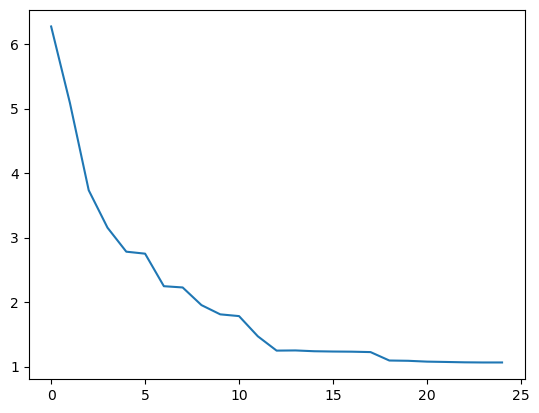

In [22]:
plt.figure()
plt.plot(fitness_record)
plt.show()

# number of atoms
in fcc:
$$N=4n^3+6n^2+3n$$
where $n$ is the number of unit cells along one edge of the cube,and N is the total number of atoms in the crystal.<br>
But in my case, I have 4 atoms in the unit cell, so I can use $$N=4n^3$$.

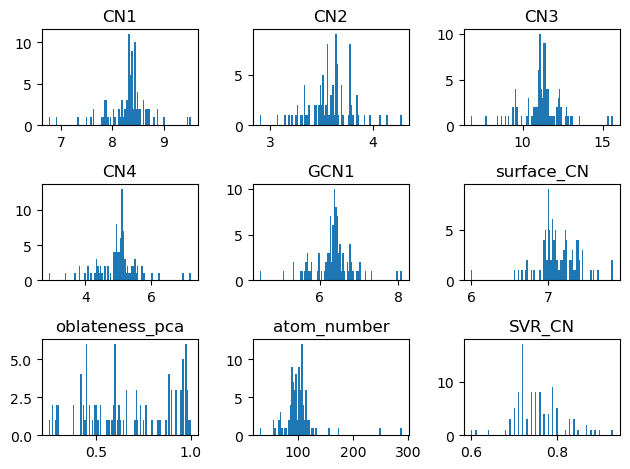

In [23]:
rankings=ranking_fitness(fitness_values)
a=[]
for i in range(len(rankings)):
    a.extend(np.where(rankings==i+1)[0])
    if len(a)>=len(rankings):
        break
# Atoms_3quarter=[last_atom_list[i] for i in a]
Atoms_3quarter=[last_atom_list[i] for i in a]

particles_descriptors=[]
pdes=[]
for i in range(len(Atoms_3quarter)):
    particles_descriptors.append(descriptor_table(Atoms_3quarter[i],all=False,descriptors=['CN1','CN2','CN3','CN4','GCN1','surface_CN','oblateness_pca','atom_number','SVR_CN']))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100,grid=False)
plt.tight_layout()

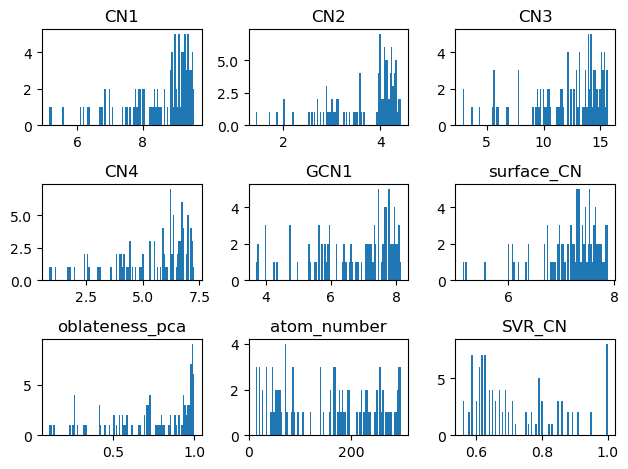

In [21]:


particles_descriptors=[]
pdes=[]
for i in range(len(ini_atom_list)):
    particles_descriptors.append(descriptor_table(ini_atom_list[i],all=False,descriptors=['CN1','CN2','CN3','CN4','GCN1','surface_CN','oblateness_pca','atom_number','SVR_CN']))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100,grid=False)
plt.tight_layout()

In [14]:
pop_ini=[ini_atom_list[i].get_positions() for i in range(len(ini_atom_list))]
pop_last=[last_atom_list[i].get_positions() for i in range(len(last_atom_list))]
matrix=np.zeros([len(pop_ini),len(pop_ini)])
no_zero=[]
for i in range(len(pop_ini)):
    for j in range(i,len(pop_ini)):
        matrix[i,j]=calculate_similarity(pop_ini[i], pop_ini[j], crowding_distance=0.1)
        if np.round(matrix[i,j],2)!=0:
            no_zero.append(matrix[i,j])

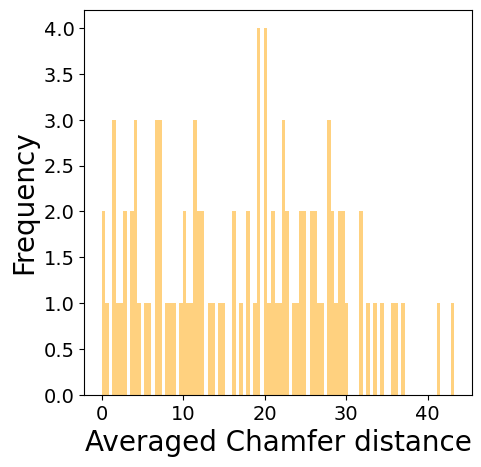

In [15]:
plt.figure(figsize=(5,5))
plt.hist(np.sum(matrix,axis=1)/len(matrix),bins=100,color='orange',alpha=0.5)
plt.xlabel("Averaged Chamfer distance",fontsize=20)
plt.ylabel("Frequency",fontsize=20)
plt.tick_params(labelsize=14)
# plt.show()
# plt.savefig("Averaged_chamfer_distance.jpeg",format='jpeg',dpi=800)

In [16]:
matrix=np.zeros([len(pop_last),len(pop_last)])
no_zero=[]
for i in range(len(pop_last)):
    for j in range(i,len(pop_last)):
        matrix[i,j]=calculate_similarity(pop_last[i], pop_last[j], crowding_distance=0.1)
        if np.round(matrix[i,j],2)!=0:
            no_zero.append(matrix[i,j])

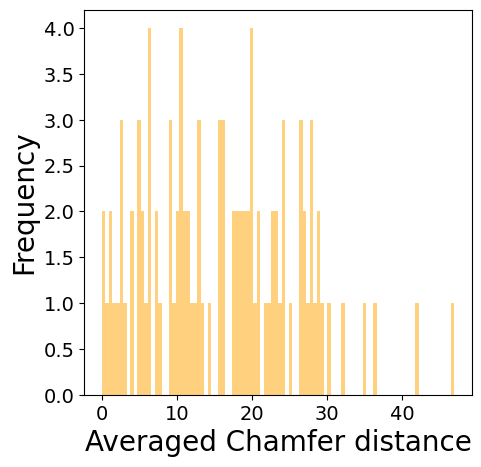

In [17]:
plt.figure(figsize=(5,5))
plt.hist(np.sum(matrix,axis=1)/len(matrix),bins=100,color='orange',alpha=0.5)
plt.xlabel("Averaged Chamfer distance",fontsize=20)
plt.ylabel("Frequency",fontsize=20)
plt.tick_params(labelsize=14)
# plt.show()
# plt.savefig("Averaged_chamfer_distance.jpeg",format='jpeg',dpi=800)

In [79]:
cdist([[1,1,1]],[[2,2,2],[3,3,3]])[0]

array([1.73205081, 3.46410162])

In [80]:
import toml
toml.load("config.toml")

{'sample_name': 'S1',
 'max_num_atoms': 200,
 'generations': 150,
 'population_size': 300,
 'lc': 3.924,
 'cross_over_rate': 0.6,
 'elite_fraction': 0.01,
 'fitness_weight': [1.0, 1.0],
 'initial_crowding_distance': 0.1,
 'niche_radius': 0.1,
 'alpha': 1,
 'initial_mutation_rate': 1,
 'mutation_rate_decay': 0.999,
 'fitness_func': 'RAE',
 'reduction': 'max',
 'plot_descriptors': ['CN1',
  'CN2',
  'CN3',
  'CN4',
  'GCN1',
  'oblateness_moment',
  'atom_number',
  'diameter_2radius',
  'SVR_CN',
  'surface_CN',
  'surface_GCN'],
 'descriptors': {'atom_number': 109, 'SVR_CN': 0.77},
 'save_config': {'percentage': 1},
 'plot_radar_conf': {'save': True,
  'descriptors': ['CN1',
   'GCN1',
   'diameter_2radius',
   'SVR_CN',
   'oblateness_moment',
   'atom_number'],
  'multiplier': [0.1, 0.1, 0.05, 1.0, 1.0, 0.005]}}

In [ ]:
def plot_sphere(center:np.array,radius:float,ax)->None:
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:20j]
    x = radius*np.cos(u)*np.sin(v)+center[0]
    y = radius*np.sin(u)*np.sin(v)+center[1]
    z = radius*np.cos(v)+center[2]
    ax.plot_surface(x, y, z, cmap='viridis', alpha=0.8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
def bond_length(xyz_filename:str):
    xyz=np.loadtxt(xyz_filename,skiprows=2,usecols=(1,2,3))
    distance=cdist([xyz[0]],xyz)
    dist=np.sort(distance[0])
    return np.round(dist[1],2)
def atom_model(xyz_filename:str,ax):
    xyz=np.loadtxt(xyz_filename,skiprows=2,usecols=(1,2,3))
    for i in range(len(xyz)):
        plot_sphere(xyz[i],1.5,ax)

# 1. intialization

In [50]:
num_lattice = 300//2
n_max = int(np.ceil(np.cbrt(num_lattice)))
lc=3.924

# 2. initialization of populations
populations,_ = ini_population(
    lc=lc,
    population_size=1000,
    num_atoms=None,
    max_num_atoms=300,
)
len(populations)

1000

In [62]:
def find_index_2d(array_2d, array_1d):
    """
    Finds the index of a 1D array within a 2D NumPy array.

    Args:
        array_2d: A 2D NumPy array.
        array_1d: A 1D NumPy array to search for.

    Returns:
        The index of the first occurrence of array_1d in array_2d, or -1 if not found.
    """
    for i, row in enumerate(array_2d):
        if np.array_equal(row, array_1d):
            return i
    return -1
index=np.unique(np.array([find_index_2d(populations,populations[i]) for i in range(900,len(populations))]))
populations_get=[populations[i] for i in range(len(populations)) if i not in index]
len(populations_get)

902

In [6]:
matrix=np.zeros([len(populations),len(populations)])
no_zero=[]
for i in range(len(populations)):
    for j in range(i,len(populations)):
        matrix[i,j]=calculate_similarity(populations[i], populations[j], crowding_distance=0.1)
        if np.round(matrix[i,j],2)!=0:
            no_zero.append(matrix[i,j])


In [7]:
%matplotlib inline

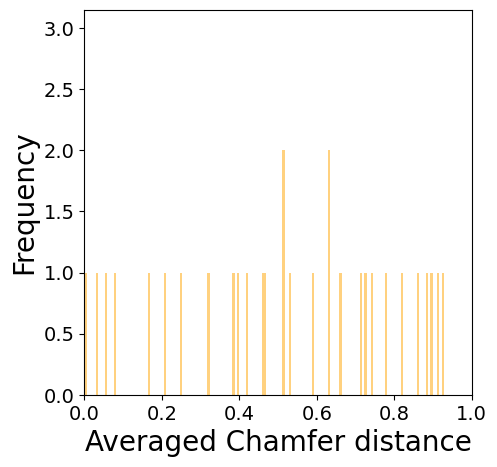

In [8]:
plt.figure(figsize=(5,5))
plt.hist(np.sum(matrix,axis=1)/len(matrix),bins=10000,color='orange',alpha=0.5)
plt.xlabel("Averaged Chamfer distance",fontsize=20)
plt.ylabel("Frequency",fontsize=20)
plt.xlim([0,1])
plt.tick_params(labelsize=14)
plt.show()

# plt.savefig("Averaged_chamfer_distance.jpeg",format='jpeg',dpi=800)

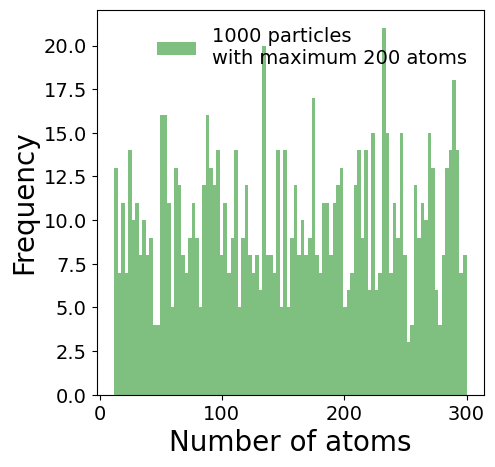

In [9]:
number_atom=[len(populations[i]) for i in range(len(populations))]
plt.figure(figsize=(5,5))
plt.hist(number_atom,bins=100,color='g',alpha=0.5,label='1000 particles\nwith maximum 200 atoms')
plt.xlabel("Number of atoms",fontsize=20)
plt.ylabel("Frequency",fontsize=20)
plt.tick_params(labelsize=14)
plt.legend(frameon=False,fontsize=14)
plt.show()
# plt.savefig("number_atoms.jpeg",format='jpeg',dpi=800)

In [10]:
len(populations)

1000

In [6]:
ini_atom_list = []
for i in range(len(populations)):
    ini_atom_list.append(
        Atoms(
            positions=populations[i],
            symbols=["Au"] * len(populations[i]),
        )
    )
view(ini_atom_list[50])


<Popen: returncode: None args: ['d:\\mamba\\envs\\NN_works\\python.exe', '-m...>

In [ ]:
particles_descriptors=[]
pdes=[]
for i in range(len(ini_atom_list)):
    particles_descriptors.append(descriptor_table(ini_atom_list[i],all=False,descriptors=['CN1','CN2','CN3','CN4','GCN1','surface_CN','oblateness_pca','atom_number','SVR_CN','diameter_2radius','MIAD']))

In [ ]:
pdes=pd.DataFrame(particles_descriptors)
# plt.figure()
pdes.hist(bins=100,grid=False,figsize=(8,8),layout=(4,3),color='blue',alpha=0.5)
plt.tight_layout()
plt.show()
# plt.savefig("descriptors_distribution.jpeg",format='jpeg',dpi=800)

In [ ]:
write_file(ini_atom_list,"initial_population")

In [ ]:
pd.DataFrame(particles_descriptors)["SVR_CN"]==1

# 2. align the coodinates

In [ ]:
%matplotlib widget

In [7]:
def align_point_clouds_pca(particle1, particle2):
    # align particle1 to particle2
    # Center the point clouds
    source_centered = particle1 - np.mean(particle1, axis=0)
    target_centered = particle2 - np.mean(particle2, axis=0)

    # Perform PCA
    if is3Ddimension(source_centered) and is3Ddimension(target_centered):
        try:
            source_pca = PCA(n_components=3).fit(source_centered)
        except RuntimeWarning:
            print(f"source particle dimension is less than 3")
        try:
            target_pca = PCA(n_components=3).fit(target_centered)
        except RuntimeWarning:
            print(f"source particle dimension is less than 3")
    else:
        return particle1
        # Align principal components
    
    
    R = np.dot(target_pca.components_.T, source_pca.components_)
    
    aligned_source = np.dot(source_centered, R.T) + np.mean(particle2, axis=0)

    return aligned_source

In [8]:
def atom_trancate_arbi(particle, theta, phi):
    def normal_vector(center,theta, phi):
        return np.array(
            [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
        )
    particle = np.array(particle)
    
    # for i in range(len(particle)):
    #     CN1,dis=getCN_dis_Oneshell(particle,particle[i],1,thickness=0.1)
    #     if CN1==12:
    #         center_get.append(particle[i])
    # if len(center_get)!=0:

    min_dim=np.min(particle)
    center_real = np.mean(particle, axis=0)
    dis=cdist([center_real],particle)[0]
    center_select=particle[dis<min_dim/2]
    print(1)
    print(center_select)
    
    center_choiced=np.random.choice(center_select)
    # else:
    #     return particle
    ## points with coordination numbers are 12 are considered as the center of planes for truncation.
    normal = normal_vector(center_choiced,theta, phi)
    trancate_particle = []
    for pos in particle:
        if (
            normal[0] * (pos[0] - center_choiced[0])
            + normal[1] * (pos[1] - center_choiced[1])
            + normal[2] * (pos[2] - center_choiced[2])
            >= 0 and [pos[0], pos[1],pos[2]] not in trancate_particle
        ):
            trancate_particle.append([pos[0], pos[1], pos[2]])
    # print(f"len(trancate_particle)={len(trancate_particle)}")
        if len(trancate_particle)<5:
             trancate_particle=[]
             for pos in particle:
                if normal[0]*(pos[0]-center_choiced[0])+normal[1]*(pos[1]-center_choiced[1])+normal[2]*(pos[2]-center_choiced[2])<=0:
                      trancate_particle.append([pos[0],pos[1],pos[2]])
    # print(f"len(trancate_particle)={len(trancate_particle)}")
    return trancate_particle


In [9]:
%matplotlib widget

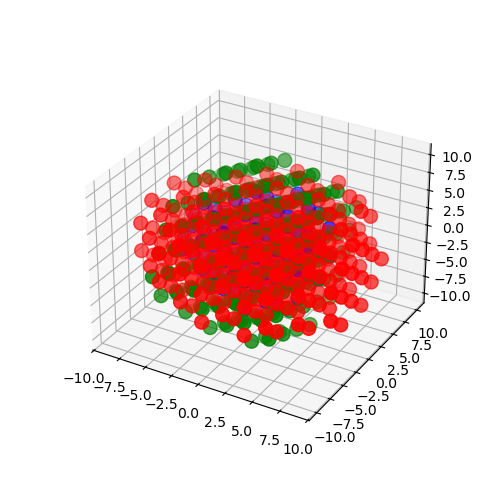

In [10]:
a1=ini_atom_list[3].get_positions()
a2=ini_atom_list[50].get_positions()
a1_r=align_point_clouds_pca(a1,a2)
plt.figure(figsize=(5,5))
ax=plt.axes(projection='3d')
ax.scatter(a1[:,0],a1[:,1],a1[:,2],color='r',marker='o',s=100,label='A')
ax.scatter(a2[:,0],a2[:,1],a2[:,2],color='b',marker='o',s=100,label='B')
ax.scatter(a1_r[:,0],a1_r[:,1],a1_r[:,2],color='g',marker='o',s=100,label='aligned')
plt.show()


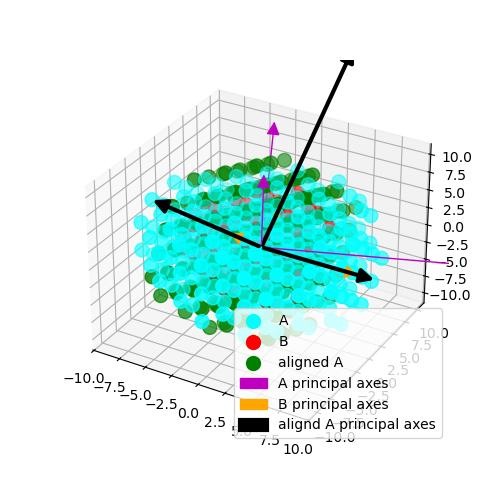

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.proj3d import proj_transform
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import linear_sum_assignment
class Arrow3D(FancyArrowPatch):

    def __init__(self, x, y, z, dx, dy, dz, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._xyz = (x, y, z)
        self._dxdydz = (dx, dy, dz)

    def draw(self, renderer):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)
        
    def do_3d_projection(self, renderer=None):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))

        return np.min(zs) 


pca1=PCA(n_components=3)
pca2=PCA(n_components=3)
pca3=PCA(n_components=3)
pca1_gamma=np.diag(pca1.fit(a1).explained_variance_)
max_pca1_gamma=np.max(pca1_gamma)   
pca2_gamma=np.diag(pca2.fit(a2).explained_variance_)
max_pca2_gamma=np.max(pca2_gamma)
weighted_pca1_comp=np.dot(pca1.fit(a1).components_.T,np.diag(np.ones(3)))#np.sqrt(pca1_gamma))
weighted_pca2_comp=np.dot(pca2.fit(a2).components_.T,np.diag(np.ones(3)))#np.sqrt(pca2_gamma))

R=np.dot(weighted_pca2_comp,weighted_pca1_comp.T)
U,s,VT=np.linalg.svd(R)
R_matrix=np.dot(U,VT)
P_align=np.dot(a1,R_matrix.T)+np.mean(a2,axis=0)
pca3_gamma=np.diag(pca3.fit(P_align).explained_variance_)
plt.figure(figsize=(5,5))
ax=plt.axes(projection='3d')
ax.scatter(a1[:,0],a1[:,1],a1[:,2],color='cyan',marker='o',s=100,label='A')
ax.scatter(a2[:,0],a2[:,1],a2[:,2],color='r',marker='o',s=100,label='B')
ax.scatter(P_align[:,0],P_align[:,1],P_align[:,2],color='g',marker='o',s=100,label='aligned A')
a=Arrow3D(0,0,0,
           pca1.fit(a1).components_[0,0]*pca1_gamma[0,0],
           pca1.fit(a1).components_[0,1]*pca1_gamma[0,0],
           pca1.fit(a1).components_[0,2]*pca1_gamma[0,0],
           mutation_scale=20,
           arrowstyle="-|>",
           linestyle='solid',color='m')
ax.add_artist(a)
b=Arrow3D(0,0,0,
           pca1.fit(a1).components_[1,0]*pca1_gamma[1,1],
           pca1.fit(a1).components_[1,1]*pca1_gamma[1,1],
           pca1.fit(a1).components_[1,2]*pca1_gamma[1,1],
           mutation_scale=20,
           arrowstyle="-|>",
           linestyle='solid',color='m')
ax.add_artist(b)
c=Arrow3D(0,0,0,
           pca1.fit(a1).components_[2,0]*pca1_gamma[2,2],
           pca1.fit(a1).components_[2,1]*pca1_gamma[2,2],
           pca1.fit(a1).components_[2,2]*pca1_gamma[2,2],
           mutation_scale=20,
           arrowstyle="-|>",
           linestyle='solid',color='m',label="A principal axes")
ax.add_artist(c)


a=Arrow3D(0,0,0,
           pca2.fit(a2).components_[0,0]*pca2_gamma[0,0]*0.8,
           pca2.fit(a2).components_[0,1]*pca2_gamma[0,0]*0.8,
           pca2.fit(a2).components_[0,2]*pca2_gamma[0,0]*0.8,
           mutation_scale=20,
           arrowstyle="-|>",
           linestyle='solid',color='orange')
ax.add_artist(a)
b=Arrow3D(0,0,0,
           pca2.fit(a2).components_[1,0]*pca2_gamma[1,1]*0.5,
           pca2.fit(a2).components_[1,1]*pca2_gamma[1,1]*0.5,
           pca2.fit(a2).components_[1,2]*pca2_gamma[1,1]*0.5,
           mutation_scale=20,
           arrowstyle="-|>",
           linestyle='solid',color='orange')
ax.add_artist(b)
c=Arrow3D(0,0,0,
           pca2.fit(a2).components_[2,0]*pca2_gamma[2,2],
           pca2.fit(a2).components_[2,1]*pca2_gamma[2,2],
           pca2.fit(a2).components_[2,2]*pca2_gamma[2,2],
           mutation_scale=20,
           arrowstyle="-|>",
           linestyle='solid',color='orange',label="B principal axes")
ax.add_artist(c)

a=Arrow3D(0,0,0,
           pca3.fit(P_align).components_[0,0]*pca3_gamma[0,0],
           pca3.fit(P_align).components_[0,1]*pca3_gamma[0,0],
           pca3.fit(P_align).components_[0,2]*pca3_gamma[0,0],
           mutation_scale=20,
           linewidth=3,
           arrowstyle="-|>",
           linestyle='solid',color='k',alpha=1)
ax.add_artist(a)
b=Arrow3D(0,0,0,
           pca3.fit(P_align).components_[1,0]*pca3_gamma[1,1],
           pca3.fit(P_align).components_[1,1]*pca3_gamma[1,1],
           pca3.fit(P_align).components_[1,2]*pca3_gamma[1,1],
           mutation_scale=20,
           linewidth=3,
           arrowstyle="-|>",
           linestyle='solid',color='k',alpha=1)
ax.add_artist(b)
c=Arrow3D(0,0,0,
           pca3.fit(P_align).components_[2,0]*pca3_gamma[2,2],
           pca3.fit(P_align).components_[2,1]*pca3_gamma[2,2],
           pca3.fit(P_align).components_[2,2]*pca3_gamma[2,2],
           mutation_scale=20,
           arrowstyle="-|>",
           linewidth=3,
           linestyle='solid',color='k',alpha=1,label='alignd A principal axes')
ax.add_artist(c)
ax.legend()

# 3. crossover

In [15]:
def crossover(lc, parent1, parent2, cross_over_rate=0.6):
    def remove_duplicates(particle, lc):
        duplicates = []
        index_get = []
        for i in range(len(particle)):
            index = np.where(
                np.isclose(cdist([particle[i]], particle)[0], 0, atol=1e-2)
            )[0]
            if len(index) > 1:
                duplicates.extend(index[1:])
            if index[0] not in duplicates:
                index_get.append(index[0])
        return np.array([particle[i] for i in index_get])

    if random.random() < cross_over_rate:
        theta = random.uniform(0, np.pi)
        phi = random.uniform(0, 2 * np.pi)
        # parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
        # parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
        try:
            parent1_up, parent1_down = atom_cut_up_down_center(parent1, theta, phi, lc)
            parent2_up, parent2_down = atom_cut_up_down_center(parent2, theta, phi, lc)
        except:
            return parent1, parent2
        parent1 = np.vstack((parent1_up, parent2_down))
        parent2 = np.vstack((parent1_down, parent2_up))
        parent1 = remove_duplicates(parent1, lc)
        parent2 = remove_duplicates(parent2, lc)
        # print(parent1_up,parent2_down)
        # print(parent1_down,parent2_up)
        return parent1, parent2
    else:
        return parent1, parent2
    
def atom_cut_up_down_center(particle, theta, phi,center="mean"):
    def normal_vector(center,theta, phi):
        return np.array(
            [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
        )

    num_atoms = len(particle)
    particle = np.array(particle)
    if num_atoms < 5:
        print("Warning particle is less than 5 atoms")
        return particle, particle

    particle = np.array(particle)
    
    # for i in range(len(particle)):
    #     CN1,dis=getCN_dis_Oneshell(particle,particle[i],1,thickness=0.1)
    #     if CN1==12:
    #         center_get.append(particle[i])
    # if len(center_get)!=0:

    min_dim=np.min(particle,axis=0)
    max_dim=np.max(particle,axis=0)
    diff=np.min(max_dim-min_dim)/2
    center_real = np.mean(particle, axis=0)
    # center_choiced=np.random.choice(center_select)
    if center=="random":
        center0=np.random.uniform(center_real[0]-np.sqrt((diff**2)/3),center_real[0]+np.sqrt((diff**2)/3))
        center1=np.random.uniform(center_real[1]-np.sqrt((diff**2)/3),center_real[1]+np.sqrt((diff**2)/3))
        center2=np.random.uniform(center_real[2]-np.sqrt((diff**2)/3),center_real[2]+np.sqrt((diff**2)/3))
    elif center=="mean":
        center0=center_real[0]
        center1=center_real[1]
        center2=center_real[2]
    else:
        raise ValueError(f"\"{center}\" can not be reconized as method, center method should be either \"random\" or \"mean\" (default: center=\"center\")!")
    center=np.array([center0,center1,center2])
    normal = normal_vector(center,theta, phi)
    trancate_upparticle = []
    trancate_downparticle = []
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>0:
            # print("down")
            trancate_upparticle.append([pos[0], pos[1], pos[2]])
        else:
            trancate_downparticle.append([pos[0], pos[1], pos[2]])
    # print(len(trancate_up_particle))
    # print(len(trancate_down_particle))
    return np.array(trancate_upparticle), np.array(trancate_downparticle),normal,center

In [16]:
def remove_duplicates(particle, lc):
        duplicates = []
        index_get = []
        for i in range(len(particle)):
            dis=cdist([particle[i]], particle)[0]
            dis_where=np.where(np.isclose(dis,0,atol=1e-1))[0]
            if len(dis_where)>1:
                index=[dis_where[j] for j in range(len(dis_where)) if dis_where[j]!=i]
                duplicates.extend(index)
        
        return np.array([particle[i] for i in range(len(particle)) if i not in duplicates])

In [19]:
parent1=ini_atom_list[3].get_positions()
parent2=ini_atom_list[5].get_positions()
# fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
# fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
# [2]. crossover and mutation to generate offsprings
theta = random.uniform(0, np.pi)
phi = random.uniform(0, 2 * np.pi)
parent1_up, parent1_down,_,_ = atom_cut_up_down_center(parent1, theta, phi)
parent2_up, parent2_down,_,_ = atom_cut_up_down_center(parent2, theta, phi)
parent1 = np.vstack((parent1_up,parent2_down))
parent2 = np.vstack((parent1_down,parent2_up))
print(len(parent1))
parent1 = remove_duplicates(parent1, lc)
print(len(parent1))
parent2 = remove_duplicates(parent2, lc)
atoms2=Atoms(positions=parent2,symbols=['Au']*len(parent1_down)+['Pt']*(len(parent2)-len(parent1_down)))
view(atoms2)

171
171


<Popen: returncode: None args: ['d:\\mamba\\envs\\NN_works\\python.exe', '-m...>

In [20]:
atoms_up=Atoms(positions=parent1_up,symbols=['Au']*len(parent1_up))
view(atoms_up)
atoms_down=Atoms(positions=parent2_down,symbols=['Pt']*len(parent2_down))
view(atoms_down)
parent1_up_r=align_point_clouds_pca(parent1_up,parent2_down)

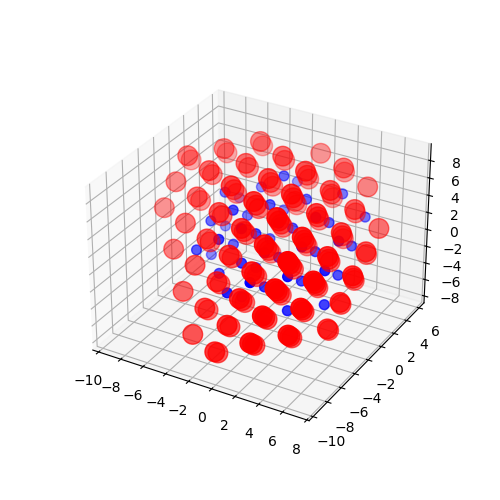

In [21]:
plt.figure(figsize=(5,5))
ax=plt.axes(projection='3d')
ax.scatter(parent1_up_r[:,0],parent1_up_r[:,1],parent1_up_r[:,2],color='r',marker='o',s=200,label='A')
ax.scatter(parent2_down[:,0],parent2_down[:,1],parent2_down[:,2],color='b',marker='o',s=50,label='B')
# ax.scatter(a1_r[:,0],a1_r[:,1],a1_r[:,2],color='g',marker='o',s=300,label='aligned')
plt.show()

In [22]:

# atoms2=Atoms(positions=parent2_down,symbols=)
view(atoms1)

NameError: name 'atoms1' is not defined

In [23]:
atom_list = []
for i in range(len(particles)):
    atom_list.append(
        Atoms(
            positions=particles[i],
            symbols=["Pt"] * len(particles[i]),
        )
    )

particles_descriptors=[]
bas=[]

for i in range(len(atom_list)):
    particles_descriptors.append(descriptor_table(atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100,grid=False)
plt.tight_layout()

NameError: name 'particles' is not defined

In [24]:
pdes

NameError: name 'pdes' is not defined

# trancate

In [25]:
def atom_trancate_arbi(particle, theta, phi,lc):
    def normal_vector(center,theta, phi):
        return np.array(
            [center[0]+np.sin(theta) * np.cos(phi), center[1]+np.sin(theta) * np.sin(phi), center[2]+np.cos(theta)]
        )
    particle = np.array(particle)
    
    # for i in range(len(particle)):
    #     CN1,dis=getCN_dis_Oneshell(particle,particle[i],1,thickness=0.1)
    #     if CN1==12:
    #         center_get.append(particle[i])
    # if len(center_get)!=0:

    min_dim=np.min(particle,axis=0)
    max_dim=np.max(particle,axis=0)
    diff=np.min(max_dim-min_dim)/2
    center_real = np.mean(particle, axis=0)
    # center_choiced=np.random.choice(center_select)
    center0=np.random.uniform(center_real[0]-np.sqrt((diff**2)/3),center_real[0]+np.sqrt((diff**2)/3))
    center1=np.random.uniform(center_real[1]-np.sqrt((diff**2)/3),center_real[1]+np.sqrt((diff**2)/3))
    center2=np.random.uniform(center_real[2]-np.sqrt((diff**2)/3),center_real[2]+np.sqrt((diff**2)/3))
    center=np.array([center0,center1,center2])
    normal = normal_vector(center,theta, phi)
    trancate_particle = []
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>0:
            # print("down")
            trancate_particle.append([pos[0], pos[1], pos[2]])

    # print(f"len(trancate_particle)={len(trancate_particle)}")
    if len(trancate_particle)<12:
        trancate_particle=[]
        print("up")
        for pos in particle:
            if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
                    trancate_particle.append([pos[0],pos[1],pos[2]])
    print(len(particle))
    print(len(trancate_particle))
    return np.array(trancate_particle),normal,center

In [26]:
%matplotlib widget

In [27]:
np.random.uniform(1,10,10)

array([8.86506253, 3.20643318, 7.56243831, 9.81849318, 3.85402676,
       5.32847892, 5.65997198, 6.42987577, 6.14603353, 2.58223697])

In [28]:
index=np.random.randint(len(populations))
data=populations[index]
theta = random.uniform(0, np.pi)
phi = random.uniform(0, 2 * np.pi)
tran_pa,normal,center=atom_trancate_arbi(populations[index], theta, phi,3.924)

ori=Atoms(positions=np.vstack((populations[index],tran_pa)),symbols=['Pt']*len(populations[index])+['Au']*len(tran_pa))
# view(ori)



167
71


77
24


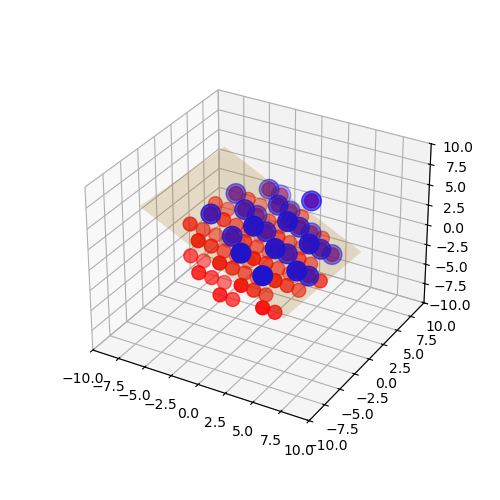

In [29]:
plt.figure(figsize=(5,5))
index=np.random.randint(len(populations))
data=populations[index]
theta = random.uniform(0, np.pi)
phi = random.uniform(0, 2 * np.pi)
tran_pa,normal,center=atom_trancate_arbi(populations[index], theta, phi,3.924)
xx, yy = np.meshgrid(range(-7,7), range(-7,7))
zz=-(normal[0]*(xx-center[0])+normal[1]*(yy-center[1]))/normal[2]+center[2]
ax=plt.axes(projection='3d')

ax.scatter(data[:,0],data[:,1],data[:,2],color='r',marker='o',s=100,label='A')
ax.plot_surface(xx, yy, zz, color='orange', alpha=0.2)
b=Arrow3D(center[0],center[1],center[2],
          center[0]+normal[0]*10,
          center[1]+normal[1]*10,
          center[2]+normal[2]*10,
           mutation_scale=20,
           arrowstyle="-|>",
           linestyle='solid',color='m')
# ax.quiver3D(center[0],center[1],center[2],
#           normal[0],
#           normal[1],
#           normal[2],
#           length=5,
#            linestyle='solid',color='m')
ax.set_xlim([-10,10])
ax.set_ylim([-10,10])
ax.set_zlim([-10,10])
# ax.add_artist(b)
ax.scatter(tran_pa[:,0],tran_pa[:,1],tran_pa[:,2],color='b',marker='o',s=200,label='B')



In [140]:
def atom_cut_up_down_center(particle, theta, phi,center_method="mean"):
    def normal_vector(center,theta, phi):
        return np.array(
            [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
        )

    num_atoms = len(particle)
    particle = np.array(particle)
    if num_atoms < 5:
        print("Warning particle is less than 5 atoms")
        return particle, particle

    particle = np.array(particle)
    
    # for i in range(len(particle)):
    #     CN1,dis=getCN_dis_Oneshell(particle,particle[i],1,thickness=0.1)
    #     if CN1==12:
    #         center_get.append(particle[i])
    # if len(center_get)!=0:

    min_dim=np.min(particle,axis=0)
    max_dim=np.max(particle,axis=0)
    diff=np.min(max_dim-min_dim)/2
    center_real = np.mean(particle, axis=0)
    # center_choiced=np.random.choice(center_select)
    if center_method=="random":
        center0=np.random.uniform(center_real[0]-np.sqrt((diff**2)/3),center_real[0]+np.sqrt((diff**2)/3))
        center1=np.random.uniform(center_real[1]-np.sqrt((diff**2)/3),center_real[1]+np.sqrt((diff**2)/3))
        center2=np.random.uniform(center_real[2]-np.sqrt((diff**2)/3),center_real[2]+np.sqrt((diff**2)/3))
    elif center_method=="mean":
        center0=center_real[0]
        center1=center_real[1]
        center2=center_real[2]
    else:
        raise ValueError(f"\"{center}\" can not be reconized as method, center method should be either \"random\" or \"mean\" (default: center_method=\"center\")!")
    center=np.array([center0,center1,center2])
    normal = normal_vector(center,theta, phi)
    trancate_upparticle = []
    trancate_downparticle = []
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>0:
            # print("down")
            trancate_upparticle.append([pos[0], pos[1], pos[2]])
        else:
            trancate_downparticle.append([pos[0], pos[1], pos[2]])
    # print(len(trancate_up_particle))
    # print(len(trancate_down_particle))
    return np.array(trancate_upparticle), np.array(trancate_downparticle),normal,center

[0.42073549 0.22984885 0.87758256]


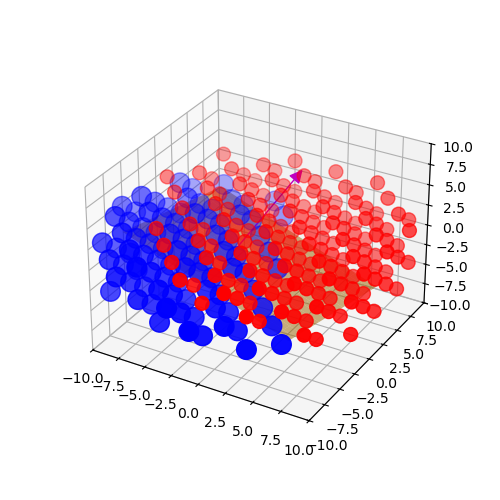

In [165]:
plt.figure(figsize=(5,5))
index=np.random.randint(len(populations))
index=14
data=populations[index]
data=ini_atom_list[index].get_positions()
theta = random.uniform(0, np.pi)
phi = random.uniform(0, 2 * np.pi)
theta=0.5
phi=0.5
tran_up,tran_down,normal,center=atom_cut_up_down_center(data, theta, phi,center_method="random")
xx, yy = np.meshgrid(range(-8,8), range(-8,8))

zz=-(normal[0]*(xx-center[0])+normal[1]*(yy-center[1]))/normal[2]+center[2]
ax=plt.axes(projection='3d')

ax.scatter(tran_up[:,0],tran_up[:,1],tran_up[:,2],color='r',marker='o',s=100,label='A')
ax.plot_surface(xx, yy, zz, color='orange', alpha=0.5)
b=Arrow3D(center[0],center[1],center[2],
          normal[0]*12,
          normal[1]*12,
          normal[2]*12,
           mutation_scale=20,
           arrowstyle="-|>",
           linestyle='solid',color='m')
ax.add_artist(b)

ax.scatter(tran_down[:,0],tran_down[:,1],tran_down[:,2],color='b',marker='o',s=200,label='B')
ax.set_xlim([-10,10])
ax.set_ylim([-10,10])
ax.set_zlim([-10,10])
print(normal)

In [399]:
# aligned=data-center
aligned=np.vstack((xx[:,0],yy[:,0],zz[:,0])).T-center
np.sum(aligned*normal,axis=1)


array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  4.4408921e-16, -4.4408921e-16,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00])

# Crossover

In [166]:

def remove_duplicates(particle, lc):
        duplicates = []
        index_get = []
        for i in range(len(particle)):
            dis=cdist([particle[i]], particle)[0]
            dis_sort=sorted(dis)
            
            if np.isclose(dis_sort[1],0,rtol=1e-5):
                  index=np.where(dis==dis_sort[1])[0][0]
                  index_get.append(sorted([i,index]))
                  
        # #     print(dis_where)
        #     if len(dis_where)>1:
        #         index=[dis_where[j] for j in range(len(dis_where)) if dis_where[j]!=i]
        #         duplicates.extend(index)
        # print(f"xyz={index_get}")
        for i in range(len(index_get)):
               duplicates.append(index_get[i][1])
        
        duplicates=np.unique(duplicates)
        print(duplicates)
        return np.array([particle[i] for i in range(len(particle)) if i not in duplicates])
def crossover(lc, parent1, parent2, cross_over_rate=0.6):
    if random.random() < cross_over_rate:
        theta = random.uniform(0, np.pi)
        phi = random.uniform(0, 2 * np.pi)
        # parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
        # parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
        try:
            parent1_up, parent1_down,_,_ = atom_cut_up_down_center(parent1, theta, phi, lc,center_method="random")
            parent2_up, parent2_down,_,_ = atom_cut_up_down_center(parent2, theta, phi, lc,center_method="random")
        except:
            return parent1, parent2
        dist=np.sort(cdist(parent1_up,parent2_down))
        parent1 = np.vstack((parent1_up, parent2_down))
        parent2 = np.vstack((parent1_down, parent2_up))
        parent1 = remove_duplicates(parent1, lc)
        parent2 = remove_duplicates(parent2, lc)
        # print(parent1_up,parent2_down)
        # print(parent1_down,parent2_up)
        return parent1, parent2
    else:
        return parent1, parent2

In [167]:
sorted([2,1])

[1, 2]

In [168]:
# def remove_duplicates(particle, lc):
#         duplicates = []
#         index_get = []
#         for i in range(len(particle)):
#             dis=cdist([particle[i]], particle)[0]
#             dis_sort=sorted(dis)
            
#             if np.isclose(dis_sort[1],0,rtol=1e-5):
#                   index=np.where(dis==dis_sort[1])[0][0]
#                   index_get.append(sorted([i,index]))
                  
#         # #     print(dis_where)
#         #     if len(dis_where)>1:
#         #         index=[dis_where[j] for j in range(len(dis_where)) if dis_where[j]!=i]
#         #         duplicates.extend(index)
#         print(f"xyz={index_get}")
#         for i in range(len(index_get)):
#                duplicates.append(index_get[i][1])
        
#         duplicates=np.unique(duplicates)
#         print(duplicates)
#         return np.array([particle[i] for i in range(len(particle)) if i not in duplicates])

def align_shapes(particle1,lattice_big):
        dist=cdist([parent1[0]],lattice_big)
        x=np.where(np.isclose(dist,np.min(dist))[0])[0]
        close=np.round(parent1[0]-lattice_big[x],5)
        print(f"shift_A={close[0]}")
        particle1_r=particle1-close[0]
        print(f"dist_after_shift={np.min(cdist([particle1_r[0]],lattice_big))}")
        return particle1


def shift_particles(particle1,particle2,lc):
        dist=cdist(particle1,particle2)
        short=np.min(dist,axis=1)
        index_A=np.where(short==np.min(short))[0][0]
        index_B=np.where(dist[index_A]==np.min(short))[0][0]
        print(f"short={np.min(dist)}")
        
        if np.min(dist)<=lc/2-1e-5:
               shift_A=particle1
        else:
               diffB_to_A=particle2[index_B]-particle1[index_A]
               shift_A=parent1+diffB_to_A
        return shift_A,particle2


In [169]:
num_lattice = 300//2  #create big lattice
n_max = int(np.ceil(np.cbrt(num_lattice)))
lattice_big = extendfcc(
    fccbasis(lc),
    lc,
    int(np.sqrt(n_max**3)),
    int(np.sqrt(n_max**3)),
    int(np.sqrt(n_max**3)),
)
#centralize the lattice
lattice_big = lattice_big - np.mean(lattice_big, axis=0)

In [170]:
np.where(np.isclose(parent1[0]-lattice_big,0,atol=1e-5).all(axis=1))[0]

array([5848], dtype=int64)

In [171]:
parent1=ini_atom_list[2].get_positions()
dist=cdist([parent1[0]],lattice_big)
x=np.where(np.isclose(dist,np.min(dist))[0])[0]
close=np.round(parent1[1]-lattice_big[x],5)
# parent1_r=np.dot(parent1,lattice_big[x][:3].T)
# dist=cdist([parent1_r[0]],lattice_big)
# x=np.where(np.isclose(dist,np.min(dist))[0])[0]
# np.round(parent1_r[0]-lattice_big[x],5)
# index_test=np.where(np.isclose(parent1[0]-lattice_big,[0,0,0],atol=lc-1e-10).all(axis=1))[0]
# diff=parent1[0]-lattice_big[index_test]
# dif
# np.min(dist)
# dist
# sigma=np.dot(close.T,close)
# vector,value,vector2=np.linalg.svd(sigma)
# q=np.diag(value/2)
# parent1=parent1+lattice_big[x[0]]
# dist=cdist([parent1[6]],lattice_big)
# x=np.where(np.isclose(dist,np.min(dist))[0])[0]
# close=np.round(parent1[6]-lattice_big[x],5)
close[0]

array([-0.   ,  1.962, -1.962])

In [172]:
parent1_r=parent1-close[0]
np.min(cdist([parent1_r[12]],lattice_big))

5.8127168167685424e-12

In [173]:
parent1=ini_atom_list[13].get_positions()
parent2=ini_atom_list[1].get_positions()
# fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
# fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
# [2]. crossover and mutation to generate offsprings
theta = random.uniform(0, np.pi)
phi = random.uniform(0, 2 * np.pi)
# theta = 0.5
# phi = 0.9
parent1=align_shapes(parent1,lattice_big)
parent2=align_shapes(parent2,lattice_big)

parent1_up, parent1_down,_,_ = atom_cut_up_down_center(parent1, theta, phi,center_method="random")
parent2_up, parent2_down,_,_ = atom_cut_up_down_center(parent2, theta, phi,center_method="random")
# parent1_up = align_shapes(parent1_up,lattice_big)

# parent2_down = align_shapes(parent2_down,lattice_big)
# parent1_down = align_shapes(parent1_down,lattice_big)
# parent2_up = align_shapes(parent2_up,lattice_big)

parent1_up,parent2_down=shift_particles(parent1_up,parent2_down,lc)
parent1_down,parent2_up=shift_particles(parent1_down,parent2_up,lc)
# parent1_up = align_shapes(parent1_up,lattice_big)

# parent2_down = align_shapes(parent2_down,lattice_big)
# parent1_down = align_shapes(parent1_down,lattice_big)
# parent2_up = align_shapes(parent2_up,lattice_big)
dist_1_up=np.sort(cdist(parent1_up,parent2_down))[:,0]
dist_1_down=np.sort(cdist(parent1_down,parent2_up))[:,0]
index_1_up=np.where(dist_1_up>1e-10)[0]
index_1_down=np.where(dist_1_down>1e-10)[0]
parent1_up=parent1_up[index_1_up]
parent1_down=parent1_down[index_1_down]
parent1 = np.vstack((parent1_up,parent2_down))
parent2 = np.vstack((parent1_down,parent2_up))
# print(len(parent1))
# parent1 = remove_duplicates(parent1, lc)
# print(len(parent1))
# parent2 = remove_duplicates(parent2, lc)
atoms2=Atoms(positions=parent2,symbols=['Au']*len(parent1_down)+['Pt']*(len(parent2)-len(parent1_down)))
view(atoms2)

shift_A=[ 1.962 -0.    -0.   ]
dist_after_shift=5.812864641272132e-12
shift_A=[ 1.962 -0.    -0.   ]
dist_after_shift=1.9619999999964595
short=3.398283684450137
short=1.9619999999999997


<Popen: returncode: None args: ['d:\\mamba\\envs\\NN_works\\python.exe', '-m...>

In [118]:
np.where(np.sort(cdist(parent1_up,parent2_down))[:,0]!=0)[0]

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76], dtype=int64)

In [119]:
atoms1=Atoms(positions=parent2,symbols=['Au']*len(parent1_down)+['Pt']*len(parent2_up))
view(atoms1)

<Popen: returncode: None args: ['d:\\mamba\\envs\\NN_works\\python.exe', '-m...>

In [121]:
atoms_test=Atoms(positions=parent1_down,symbols=['Au']*len(parent1_down))
view(atoms_test)

<Popen: returncode: None args: ['d:\\mamba\\envs\\NN_works\\python.exe', '-m...>

In [122]:
atoms_test=Atoms(positions=parent2_up,symbols=['Pt']*len(parent2_up))
view(atoms_test)

<Popen: returncode: None args: ['d:\\mamba\\envs\\NN_works\\python.exe', '-m...>

# convex hull

In [160]:
def convex_particle(particle, lattice_big, lc):
    indices = []
    try:
        hull = ConvexHull(particle)
    except QhullError and ValueError:
        # print("less than 3 dimensions")
        # print(particle)
        return particle
    for points in lattice_big:
        if is_point_in_hull(points, hull, lc):
            indices.extend(
                np.where(np.all(np.isclose(lattice_big,points, atol=1e-5), axis=1))[0]
            )
    # print(len(indices))
    # print(len(particle))
    return np.array([lattice_big[i] for i in indices]),hull,particle


def is_point_in_hull(point, hull, lc):
    equations = hull.equations
    # print(np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=0))
    return np.all(
        np.dot(equations[:, :-1], point) + equations[:, -1] <= 1e-5
    )

In [161]:
import plotly.graph_objects as go
convex_p1,hull,particle=convex_particle(parent2, lattice_big, lc)
xc = particle[hull.vertices]
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=particle[:, 0], 
                        y=particle[:, 1], 
                        z=particle[:, 2], 
                        mode='markers', 
                        marker=dict(size=10, color='blue')))
fig.add_trace(go.Mesh3d(x=xc[:, 0], 
                        y=xc[:, 1], 
                        z=xc[:, 2], 
                        color="orange", 
                        
                        opacity=.5,
                        alphahull=0))
fig.add_trace(go.Scatter3d(x=convex_p1[:, 0],
                        y=convex_p1[:, 1], 
                        z=convex_p1[:, 2], 
                        mode='markers', 
                        marker=dict(size=5, color='red')))
fig.add_trace(go.Scatter3d(x=lattice_big[:, 0],
                        y=lattice_big[:, 1], 
                        z=lattice_big[:, 2], 
                        mode='markers', 
                        marker=dict(size=1, color='green')))
fig
# atoms_p1=Atoms(positions=convex_p1,symbols=['Au']*len(convex_p1))
# view(atoms_p1)


In [190]:
view(Atoms(positions=convex_p1,symbols=['Pt']*len(convex_p1)))

<Popen: returncode: None args: ['d:\\mamba\\envs\\NN_works\\python.exe', '-m...>

# mutation

In [163]:
def mutation(particle, lc, max_num_atoms, mutation_rate=0.3):
    mr = random.uniform(0, 1)
    # if mr <= mutation_rate/3:  # / 2:
    #     # renum = 0
    #     # theta = random.uniform(0, np.pi)
    #     # phi = random.uniform(0, 2 * np.pi)
    #     # particle_update = atom_trancate_center(particle, theta, phi)
    #     # while len(particle_update) < 5 and renum < 5:
    #     #     theta = random.uniform(0, np.pi)
    #     #     phi = random.uniform(0, 2 * np.pi)
    #     #     # if renum==0:
    #     #     #     print("no good 1")
    #     #     particle_update = atom_trancate_center(particle, theta, phi)
    #     #     renum += 1
    if mr <= mutation_rate * 3 / 4:  # and mr <= mutation_rate * 2 / 3:
        theta = random.uniform(0, np.pi)
        phi = random.uniform(0, 2 * np.pi)
        particle_update1,particle_update2,_,_ = atom_cut_up_down_center(particle, theta, phi,center_method="mean")
        if len(particle_update1)<=len(particle_update2):
            particle_update = particle_update2
        else:
            particle_update = particle_update1
    elif mr >= mutation_rate * 3 / 4 and mr <= mutation_rate:
        # 2. initialization of populations
        particle_update = ini_population(
            lc=lc,
            population_size=1,
            # lattice_big=lattice_big,
            max_num_atoms=max_num_atoms,
            num_atoms=None,
        )[0][0]

    else:
        particle_update = particle
    
    return particle_update


In [189]:
mutation1=mutation(convex_p1,lc,300,mutation_rate=1)
Atoms(positions=mutation1,symbols=['Au']*len(mutation1))
view(Atoms(positions=mutation1,symbols=['Pt']*len(mutation1)))

<Popen: returncode: None args: ['d:\\mamba\\envs\\NN_works\\python.exe', '-m...>

[-0.92315897  0.04960708 -0.38120421]


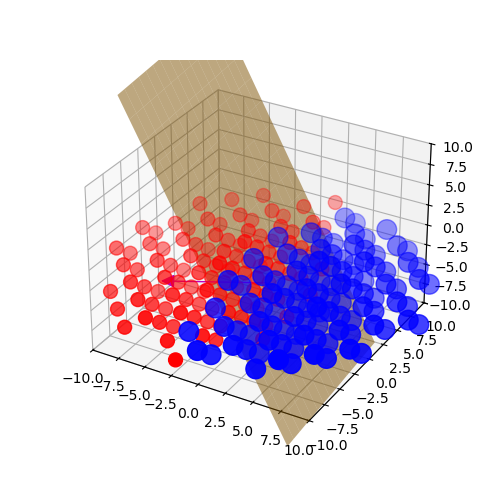

In [181]:
plt.figure(figsize=(5,5))
index=np.random.randint(len(populations))
index=14
data=convex_p1
theta = random.uniform(0, np.pi)
phi = random.uniform(0, 2 * np.pi)
tran_up,tran_down,normal,center=atom_cut_up_down_center(data, theta, phi,center_method="mean")
xx, yy = np.meshgrid(range(-8,8), range(-8,8))

zz=-(normal[0]*(xx-center[0])+normal[1]*(yy-center[1]))/normal[2]+center[2]
ax=plt.axes(projection='3d')

ax.scatter(tran_up[:,0],tran_up[:,1],tran_up[:,2],color='r',marker='o',s=100,label='A')
ax.plot_surface(xx, yy, zz, color='orange', alpha=0.5)
b=Arrow3D(center[0],center[1],center[2],
          normal[0]*12,
          normal[1]*12,
          normal[2]*12,
           mutation_scale=20,
           arrowstyle="-|>",
           linestyle='solid',color='m')
ax.add_artist(b)

ax.scatter(tran_down[:,0],tran_down[:,1],tran_down[:,2],color='b',marker='o',s=200,label='B')
ax.set_xlim([-10,10])
ax.set_ylim([-10,10])
ax.set_zlim([-10,10])
print(normal)

In [175]:
tran_up

array([[-8.829,  4.905, -0.981],
       [-6.867,  2.943, -0.981],
       [-4.905,  0.981, -0.981],
       [-6.867,  6.867, -0.981],
       [-4.905,  4.905, -0.981],
       [-4.905,  6.867, -2.943],
       [-6.867,  4.905, -2.943],
       [-4.905,  8.829, -0.981],
       [-2.943,  2.943, -0.981],
       [-0.981,  0.981, -0.981],
       [-0.981,  2.943, -2.943],
       [-2.943,  6.867, -4.905],
       [-0.981,  4.905, -4.905],
       [-2.943,  6.867, -0.981],
       [-0.981,  4.905, -0.981],
       [-0.981,  6.867, -2.943],
       [-2.943,  4.905, -2.943],
       [-0.981,  8.829, -0.981],
       [-2.943,  8.829, -2.943],
       [ 2.943, -0.981, -2.943],
       [ 0.981,  2.943, -4.905],
       [ 0.981,  2.943, -0.981],
       [ 2.943,  2.943, -2.943],
       [ 0.981,  0.981, -2.943],
       [ 0.981,  6.867, -4.905],
       [ 2.943,  4.905, -4.905],
       [ 0.981,  4.905, -6.867],
       [ 0.981,  6.867, -0.981],
       [ 2.943,  4.905, -0.981],
       [ 2.943,  6.867, -2.943],
       [ 0

In [ ]:
dist=cdist(parent1_down,parent2_up)
short=np.min(dist,axis=1)
index_A=np.where(short==np.min(short))[0][0]
index_B=np.where(dist[index_A]==np.min(short))[0][0]
print(index_A,index_B)
diffA_to_B=parent1_down[index_A]-parent2_up[index_B]
shift_A=parent1_down-diffA_to_B-lc/2

In [ ]:
parent1_down[0]-parent1_down[3]

In [ ]:
atoms1a=Atoms(positions=shift_A,symbols=['Au']*len(shift_A))
view(atoms1a)

In [ ]:
parent2a = np.vstack((shift_A,parent2_up))
parent2a = remove_duplicates(parent2a, lc)
atoms2a=Atoms(positions=parent2a,symbols=['Au']*len(shift_A)+['Pt']*(len(parent2a)-len(shift_A)))
view(atoms2a)

In [ ]:
pdes[pdes['Departure from sphere(moment)']<0.03]

In [ ]:
list_par=[]
descriptors=["diameter_2radius",
                "surface ratio",
                "atom_number"]

for i in range(pdes.shape[0]):
    dis=[]
    for d in descriptors:
        dis.append(pdes.iloc[i][d])
    list_par.append([dis])

par_dict={}
list_read=[]
for i in range(pdes.shape[0]):
    indices=np.where(np.isclose(list_par[i],list_par,rtol=1e-2).all(axis=1))[0]
    # print(indices)
    
    # print(list_read)
    if i not in list_read:
        list_read.extend(indices)
        par_dict[f"{list_par[i]}"]={"indices":indices,"num":len(indices)}


par_dict=pd.DataFrame(par_dict)
# print(par_dict)
i=0
index_get=[]
values=[]
for k,v in par_dict.items():
    if v['num']>10:
        values.append(k)
        index_get.append(i)
    i+=1

plt.figure()
plt.bar(np.arange(par_dict.shape[1]),par_dict.loc["num"])
plt.xlabel(descriptors)
plt.xticks(index_get,values,rotation=90,fontsize=9)  
plt.tight_layout()

In [ ]:
# par_dict['[7.5, 2.95, 8.77, 3.41]']
view(last_atom_list[par_dict['[[11.21, 0.86, 42.0]]']['indices'][0]],viewer='x3d')

In [ ]:
view(last_atom_list[90],viewer='x3d')

In [ ]:
from shape_proj_util.geo_tools.convenient_datasoup import *
data=particle_database(element='Pt')
data.predefine_data(3.77)
table=data.shape_info().T



In [ ]:
table

In [ ]:
min(population, key=lambda x: calculate_similarity(x, individual))
# data.search_by_name("OCT_4")


# ellipsoid

In [ ]:
from shape_proj_util.geo_tools import geometry

In [ ]:
view(last_atom_list[0],viewer='x3d')

In [ ]:
x=np.array(geometry.ellipsoid(last_atom_list[9]))
x




In [ ]:
%matplotlib widget

In [ ]:
# import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

def draw_ellipsoid(atoms):
    position=atoms.get_positions()
    radii=geometry.ellipsoid(atoms)
    center=radii[3]
    rotation=radii[4]
    # Create a grid of points
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    
    # Create the ellipsoid points in the local space
    x = radii[0] *  np.outer(np.sin(v), np.cos(u))
    y = radii[1] *  np.outer(np.sin(v), np.sin(u))
    z = radii[2] *  np.outer(np.cos(v), np.ones_like(u))



    
    for i in range(len(x)):
        for j in range(len(x[0])):
            # print(np.dot([x[i, j], y[i, j], z[i, j]], radii) * rotation + center)
            [x[i, j], y[i, j], z[i, j]] = np.dot(rotation,[x[i, j], y[i, j], z[i, j]]) + center

    # Plot ellipsoid
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x, y, z,  rstride=4, cstride=4, color='cyan', alpha=0.3)
    ax.scatter(position[:,0], position[:,1], position[:,2], color='red')
    # fig = go.Figure(data=[
    #     go.Mesh3d(
    #         x=x,
    #         y=y,
    #         z=z,
    #         color='cyan',
    #         opacity=1,
    #         alphahull=-1
    #     ),
    #     go.Scatter3d(
    #         x=position[:, 0],
    #         y=position[:, 1],
    #         z=position[:, 2],
    #         mode='markers',
    #         marker=dict(
    #             size=2,
    #             color='red'
    #         )
    #     )
    # ])
    
    # fig.update_layout(
    #     scene=dict(
    #         xaxis_title='X Axis',
    #         yaxis_title='Y Axis',
    #         zaxis_title='Z Axis'
    #     ),
    #     title='3D Ellipsoid and Atom Positions'
    # )
    # fig.write_html('ellipsoid_plot.html')
    # fig.show()
    


    

In [ ]:
A_inv=ellipsoid(last_atom_list[6])
U, s, rotation = np.linalg.svd(A_inv)
U

In [ ]:
draw_ellipsoid(last_atom_list[3])